# Demo: a multilayer perceptron written from scratch in NumPy

This notebook is a short tour of the repository. It trains a small network for a few epochs
using only the code in `src/` (no deep-learning framework), checks the backpropagation
numerically, and then loads the final model produced by `experiments/final_evaluation.py`.

Run it from the repository root (`jupyter notebook notebooks/demo.ipynb`).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_splits, one_hot
from src.model import MLP
from src.training import train, evaluate
from src.gradcheck import gradient_check

d = load_splits(os.path.abspath('../data'))
print({k: v.shape for k, v in d.items()})

{'X_train': (50000, 784), 'y_train': (50000,), 'X_val': (10000, 784), 'y_val': (10000,), 'X_test': (10000, 784), 'y_test': (10000,)}


## 1. Backpropagation is verified against finite differences

In [2]:
rng = np.random.default_rng(0)
X, y = rng.random((8, 20)), rng.integers(0, 10, 8)
small = MLP([20, 10, 10], hidden_activation='relu', loss='softmax_ce', init='he', dtype=np.float64)
gradient_check(small, X, one_hot(y, dtype=np.float64))

{'W1': 1.5820398742999815e-08,
 'b1': 2.9670814918824773e-10,
 'W2': 2.965799266094462e-07,
 'b2': 1.9000950927120866e-10}

## 2. Train a 784-64-10 network for 3 epochs (mini-batch SGD, validation monitoring)

In [3]:
model = MLP([784, 64, 10], hidden_activation='relu', loss='softmax_ce', init='he', seed=0)
hist = train(model, d['X_train'], d['y_train'], d['X_val'], d['y_val'],
             epochs=3, batch_size=64, lr=0.1, seed=0)

  epoch  1/3 | train loss 0.2663 acc 0.9259 | val loss 0.2858 acc 0.9198


  epoch  2/3 | train loss 0.2010 acc 0.9435 | val loss 0.2212 acc 0.9373


  epoch  3/3 | train loss 0.1847 acc 0.9474 | val loss 0.2130 acc 0.9372


## 3. Load the final selected model and look at some predictions
The test-set accuracy of this model is reported once, in the README.

{'layer_sizes': [784, 128, 10], 'hidden_activation': 'relu', 'loss': 'softmax_ce', 'init': 'he', 'seed': 0, 'dtype': 'float32'}


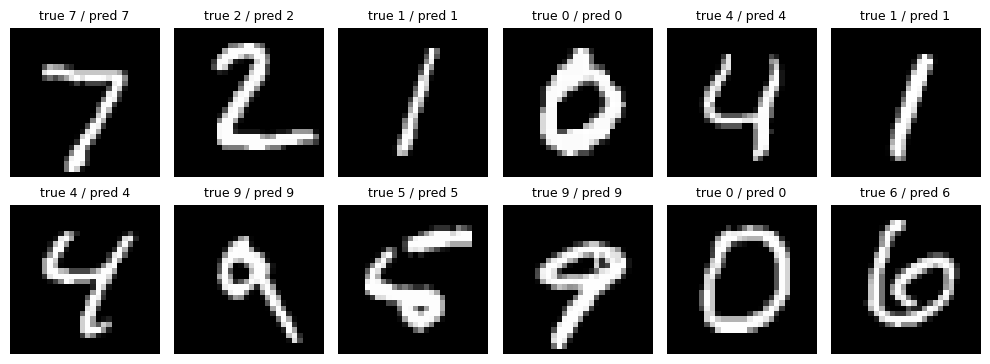

In [4]:
final = MLP.load('../results/models/final_model_seed0.npz')
print(final.config)
idx = np.arange(12)
pred = final.predict(d['X_test'][idx])
fig, axes = plt.subplots(2, 6, figsize=(10, 3.8))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(d['X_test'][i].reshape(28, 28), cmap='gray'); ax.axis('off')
    ax.set_title(f"true {d['y_test'][i]} / pred {pred[i]}", fontsize=9)
plt.tight_layout(); plt.show()

## 4. What did the hidden units learn?
Input weights of the first 16 units of the final model (red = positive, blue = negative). The full analysis is in `experiments/feature_analysis.py`.

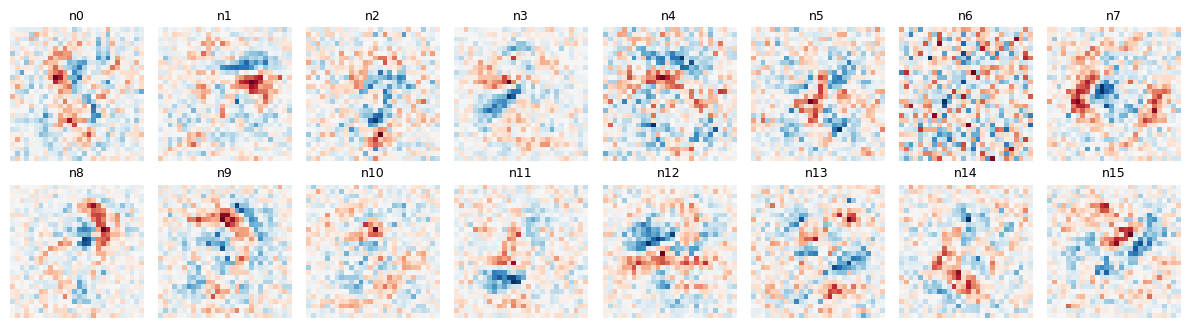

In [5]:
W1 = final.dense[0].W
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for u, ax in enumerate(axes.ravel()):
    w = W1[:, u].reshape(28, 28); lim = np.abs(w).max()
    ax.imshow(w, cmap='RdBu_r', vmin=-lim, vmax=lim); ax.axis('off'); ax.set_title(f'n{u}', fontsize=9)
plt.tight_layout(); plt.show()